In [240]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

In [241]:
#mason df_cleaned is declared to the cleaned dataset from the Midterm

df_cleaned = pd.read_csv('cleaned_hotel_bookings.csv')

In [242]:
#mason check initial dataset before Split

df_cleaned.head(1)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,total_of_special_requests,reservation_status,reservation_status_date,month,total_guests,stay_duration,is_family,arrival_date,arrival_month_num,is_weekend_arrival
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,Check-Out,00:00.0,1,2,0,0,7/1/2015,7,0


In [243]:
#mason shape of dataset before Split

df_cleaned.shape

(119390, 37)

In [244]:
#mason Split cleaned dataset into 70 train/30 temp

train_df, temp_df = train_test_split(df_cleaned, test_size=0.3, random_state=42)

In [245]:
#mason Splitting temp_df into validation_df and test_df so its 15/15

validation_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

In [246]:
#mason checking shape of new Splits comapred to total shape to ensure 70/15/15 proportion of Splits is correct

print("-- Shape of New Splits --")
print()
print()
print("-Total Dataset Before Split (100%):")
print(df_cleaned.shape)
print()
print("-Train Split (70%):")
print(train_df.shape)
print()
print("-Validation Split (15%):")
print(validation_df.shape)
print()
print("-Test Split (15%):")
print(test_df.shape)
print()

-- Shape of New Splits --


-Total Dataset Before Split (100%):
(119390, 37)

-Train Split (70%):
(83573, 37)

-Validation Split (15%):
(17908, 37)

-Test Split (15%):
(17909, 37)



In [247]:
#mason download the Splits to .csv format for later use

train_df.to_csv("Train.csv", index=False)
validation_df.to_csv("Validation.csv", index=False)
test_df.to_csv("Test.csv", index=False)

In [248]:
#mason confirmed downloaded files

!ls -1

cleaned_hotel_bookings.csv
sample_data
Test.csv
Train.csv
Validation.csv


In [250]:
# mason ############# use Train.csv(declared as df_train) from this point (im pretty sure) and not cleaned_hotel_bookings.csv

In [251]:
# mason declare df_train to read the .csv sheet we downloaded earlier

df_train = pd.read_csv('Train.csv')

In [252]:
# mason shape of train dataset
df_train.shape

(83573, 37)

In [253]:
# mason inspect train dataset to see what we're working with
df_train.head(4)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,total_of_special_requests,reservation_status,reservation_status_date,month,total_guests,stay_duration,is_family,arrival_date,arrival_month_num,is_weekend_arrival
0,Resort Hotel,1,122,2016,December,53,27,0,4,2,...,2,Canceled,00:00.0,1,2,4,0,12/27/2016,12,0
1,City Hotel,1,20,2015,July,30,22,0,2,2,...,0,Canceled,00:00.0,1,2,2,0,7/22/2015,7,0
2,City Hotel,0,87,2017,April,16,16,2,3,3,...,0,Check-Out,00:00.0,1,3,5,1,4/16/2017,4,1
3,Resort Hotel,0,0,2017,February,5,2,0,1,1,...,1,Check-Out,00:00.0,1,1,1,0,2/2/2017,2,0


In [ ]:

####################################################### LOGISTIC REGRESSION  ######################################################


Train Accuracy(0-1) : 1.0


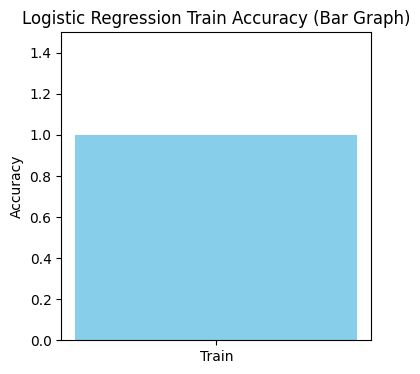

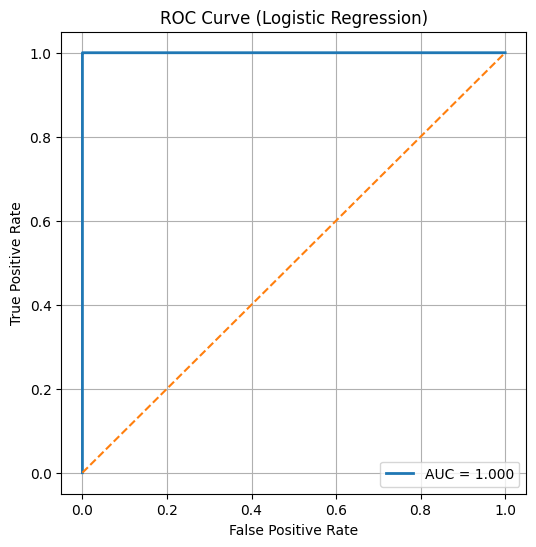

In [254]:
# mason
# starting logistic regression

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# splitting into features and label
X_train = df_train.drop("is_canceled", axis=1)  # label column
y_train = df_train["is_canceled"]

# IDENTIFY CATEGORICAL AND NUMERICAL COLUMNS
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
numerical_cols = X_train.select_dtypes(include='number').columns

# PROPER PREPROCESSING:
# - One-hot encode categorical columns ONLY
# - Scale numerical columns (keeps their numeric information)
preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ("scale", StandardScaler(), numerical_cols)
    ]
)

# applying preprocessing
X_train_processed = preprocessor.fit_transform(X_train);

# creating and training logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_processed, y_train);

# evaluating accuracy on train set
train_acc = model.score(X_train_processed, y_train)
print("Train Accuracy(0-1) :", train_acc)


# Bar Graph

plt.figure(figsize=(4,4))
plt.bar(["Train"], [train_acc], color='skyblue')
plt.ylim(0,1.5)
plt.ylabel("Accuracy")
plt.title("Logistic Regression Train Accuracy (Bar Graph)")
plt.show()


# ROC CURVE graph

from sklearn.metrics import roc_curve, auc

# model predicted probabilities for the positive class
y_prob = model.predict_proba(X_train_processed)[:, 1]

# compute ROC values
fpr, tpr, thresholds = roc_curve(y_train, y_prob)
roc_auc = auc(fpr, tpr)

# plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.legend()
plt.grid(True)
plt.show()


In [255]:
################################################## DECISION TREE CLASSIFIER #######################################################

Train Accuracy(0-1) : 1.0



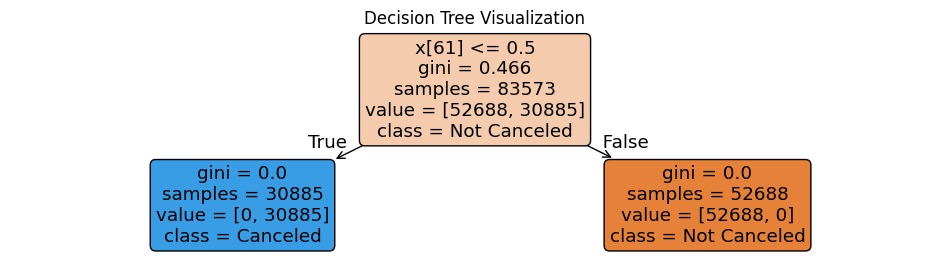

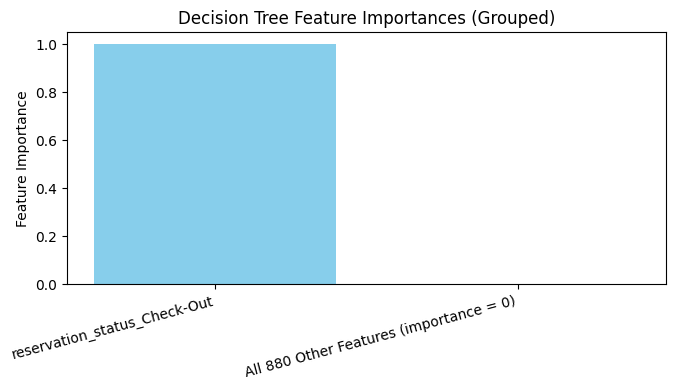

In [256]:
# mason
# starting decision tree classsifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# loading the training dataset
df_train = pd.read_csv("Train.csv")

# splitting into features and label
X = df_train.drop("is_canceled", axis=1)
y = df_train["is_canceled"]

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=np.number).columns

# Create a column transformer for preprocessing
preprocessor = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    (StandardScaler(), numerical_cols)
)

# applying preprocessing to the features
X_processed = preprocessor.fit_transform(X)

# creating and training decision tree model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1
)
dt_model.fit(X_processed, y)

# evaluating accuracy on training set
train_acc = dt_model.score(X_processed, y)
print("Train Accuracy(0-1) :", train_acc)
print()

# visual of the decision tree
plt.figure(figsize=(12,3))
plot_tree(dt_model,
          filled=True,
          class_names=["Not Canceled","Canceled"],
          rounded=True,
          max_depth=3)
plt.title("Decision Tree Visualization")
plt.show()


# FEATURE IMPORTANCE BAR GRAPH

# Get all feature names created by preprocessing
encoded_cat_cols = list(
    preprocessor.named_transformers_["onehotencoder"].get_feature_names_out(categorical_cols)
)
feature_names = encoded_cat_cols + list(numerical_cols)

# Extract importances
importances = dt_model.feature_importances_

# Identify the single non-zero feature
non_zero_indices = np.where(importances > 0)[0]

if len(non_zero_indices) == 0:
    top_feature_name = "No Features Used"
    top_feature_importance = 0
else:
    top_idx = non_zero_indices[0]
    top_feature_name = feature_names[top_idx]
    top_feature_importance = importances[top_idx]

# Count how many features have zero importance
zero_count = np.sum(importances == 0)

# Prepare labels and values for grouped bar chart
labels = [top_feature_name, f"All {zero_count} Other Features (importance = 0)"]
values = [top_feature_importance, 0]

# Plot
plt.figure(figsize=(7,4))
plt.bar(labels, values, color=['skyblue', 'lightgray'])
plt.ylabel("Feature Importance")
plt.title("Decision Tree Feature Importances (Grouped)")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()





In [257]:
############################################# RANDOM FOREST #################################################################

train accuracy: 1.0


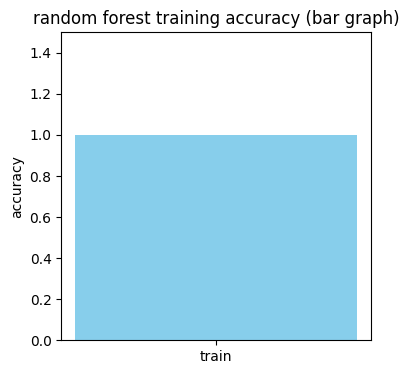

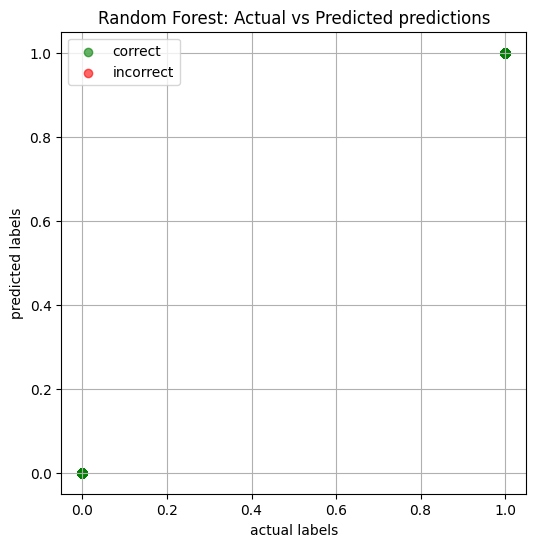

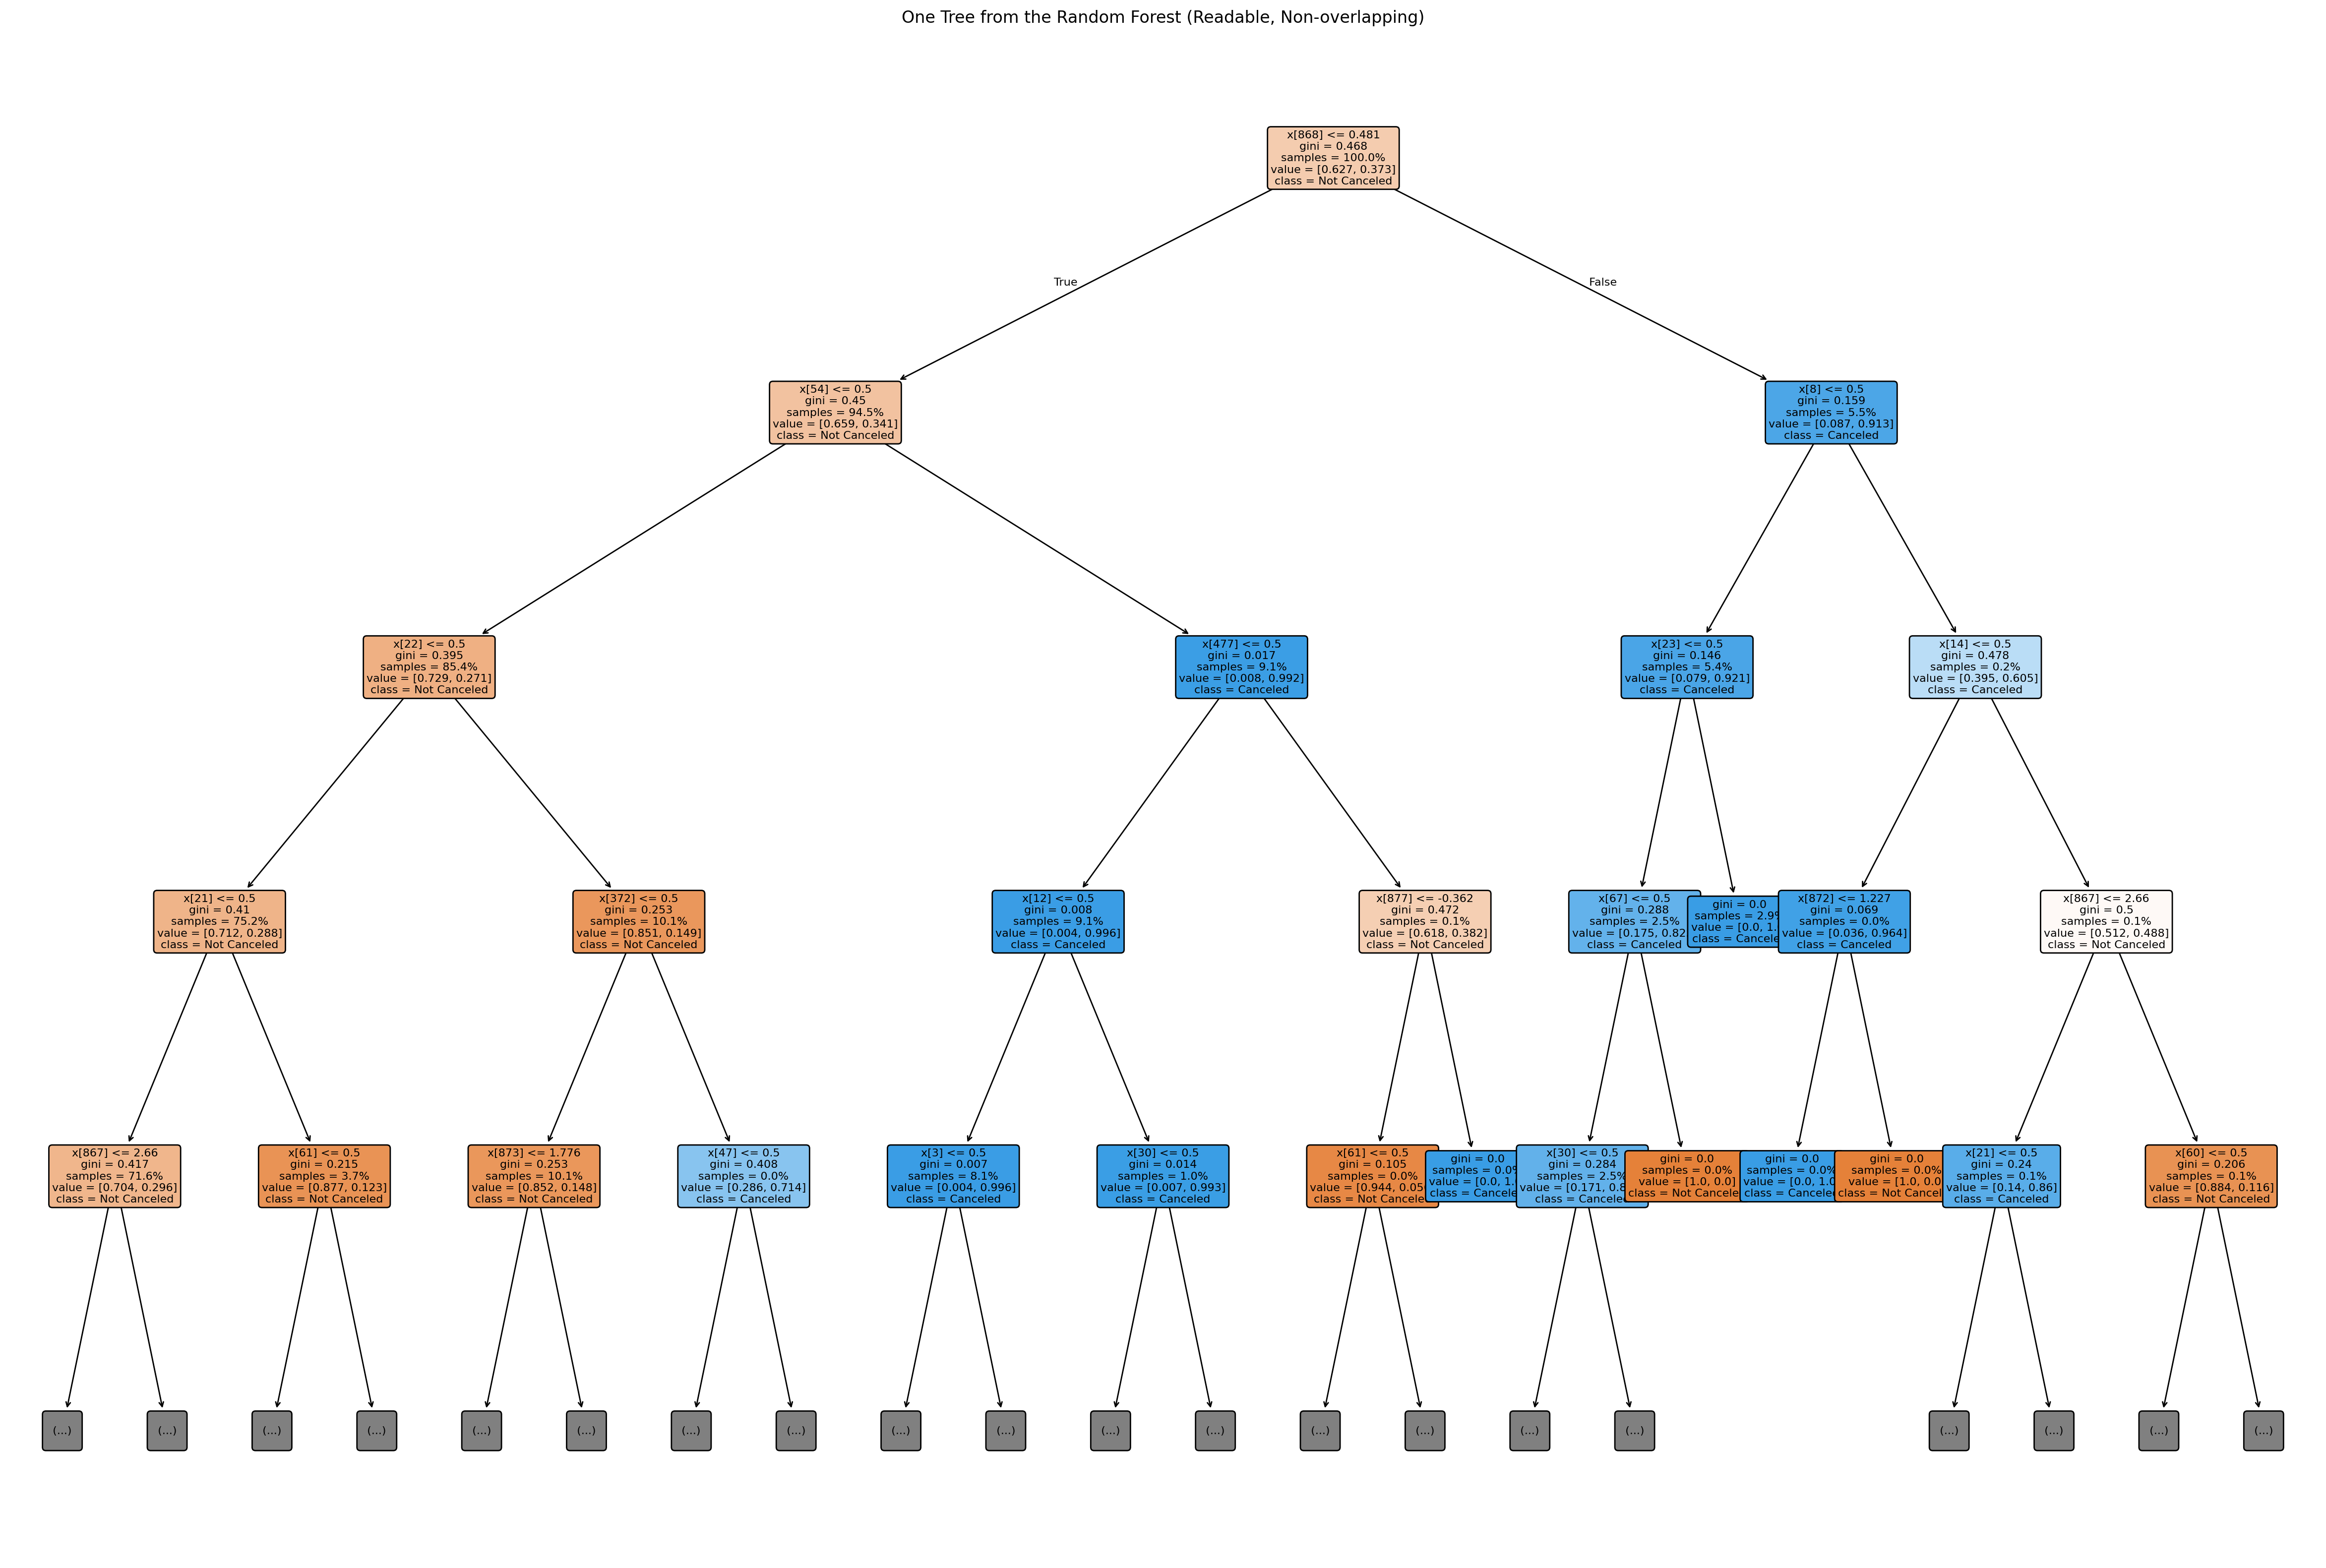

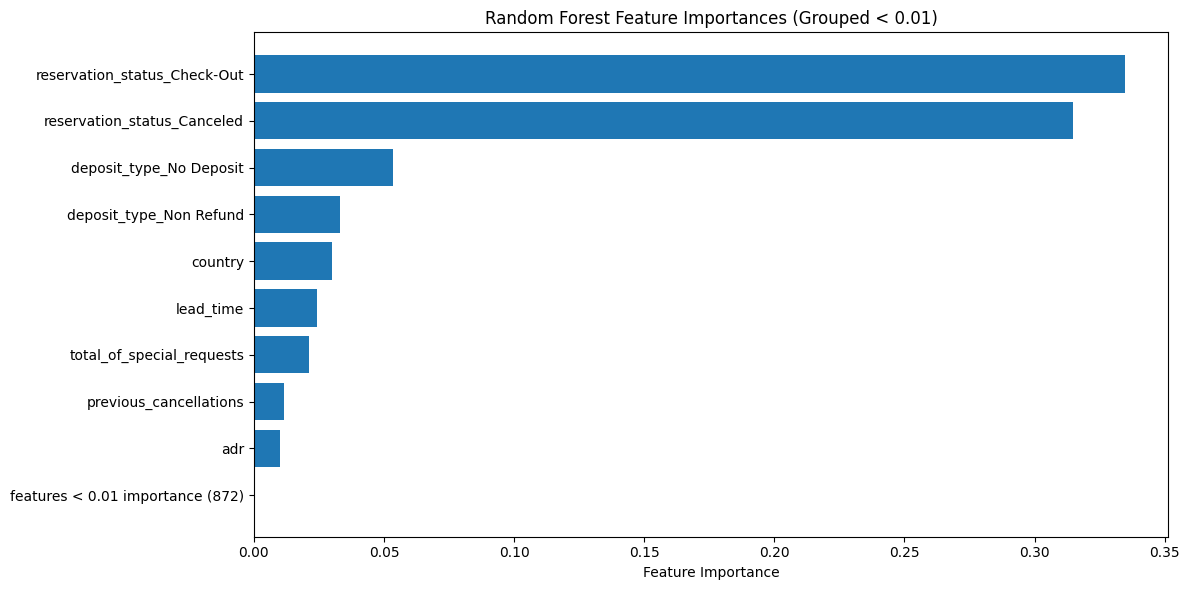

In [258]:
# mason
# starting random forest classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import make_column_transformer

# splitting into features and label
X = df_train.drop("is_canceled", axis=1)
y = df_train["is_canceled"]

# identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=np.number).columns

# create a column transformer for preprocessing
preprocessor = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    (StandardScaler(), numerical_cols)
)

# applying preprocessing to the features
X_processed = preprocessor.fit_transform(X)

# creating and training random forest model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_processed, y)

# evaluating accuracy on training set
train_acc = rf_model.score(X_processed, y)
print("train accuracy:", train_acc)

# creating a bar graph of training accuracy
plt.figure(figsize=(4,4))
plt.bar(["train"], [train_acc], color='skyblue')
plt.ylim(0,1.5)
plt.ylabel("accuracy")
plt.title("random forest training accuracy (bar graph)")
plt.show()

# creating a scatter plot showing correct vs incorrect predictions
y_pred = rf_model.predict(X_processed)

plt.figure(figsize=(6,6))

# correct predictions
correct = y == y_pred
plt.scatter(y[correct], y_pred[correct], alpha=0.6, color='green', label='correct')

# incorrect predictions
incorrect = y != y_pred
plt.scatter(y[incorrect], y_pred[incorrect], alpha=0.6, color='red', label='incorrect')

plt.xlabel("actual labels")
plt.ylabel("predicted labels")
plt.title("Random Forest: Actual vs Predicted predictions")
plt.legend()
plt.grid(True)
plt.show()


# Visualizing One Tree From The Random Forest
single_tree = rf_model.estimators_[0]  # take the first tree in the forest

plt.figure(figsize=(30,20), dpi=200)
plot_tree(
    single_tree,
    filled=True,
    class_names=["Not Canceled","Canceled"],
    rounded=True,
    fontsize=8,
    max_depth=4,  # limit depth to prevent overlap
    proportion=True
)
plt.title("One Tree from the Random Forest (Readable, Non-overlapping)")
plt.show()


# feature importance bar graph

# Get one-hot encoded feature names
encoded_cat_cols = list(
    preprocessor.named_transformers_['onehotencoder'].get_feature_names_out(categorical_cols)
)

# Combine with numerical column names
feature_names = encoded_cat_cols + list(numerical_cols)

importances = rf_model.feature_importances_

# Separate features with importance >= 0.01 and < 0.01
high_idx = np.where(importances >= 0.01)[0]
low_idx = np.where(importances < 0.01)[0]

high_features = [feature_names[i] for i in high_idx]
high_importances = importances[high_idx]

low_count = len(low_idx)

# Add grouped low-importance bar if any exist
if low_count > 0:
    high_features.append(f"features < 0.01 importance ({low_count})")
    high_importances = np.append(high_importances, 0)

# Sort bars by importance descending
sorted_idx = np.argsort(high_importances)[::-1]
sorted_features = [high_features[i] for i in sorted_idx]
sorted_importances = high_importances[sorted_idx]

# Adjust figure height dynamically
height = max(6, len(sorted_features) * 0.4)

plt.figure(figsize=(12, height))
plt.barh(sorted_features, sorted_importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances (Grouped < 0.01)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [259]:
################################################# GRADIENT BOOSTING CLASSIFIER ####################################################